<a href="https://colab.research.google.com/github/computacao-aplicada/lab01-eda-gustavoreiis/blob/main/Wine_Quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
# Carregando o dataset
wineRed = pd.read_csv('/content/winequality-red.csv', sep=";")
wineRed['type'] = 'tinto'

wineWhite = pd.read_csv('/content/winequality-white.csv', sep=";")
wineWhite['type'] = 'branco'

df_wine = pd.concat([wineRed, wineWhite], ignore_index=True)

In [10]:
df_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,tinto
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,tinto
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,tinto
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,tinto
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,tinto


In [11]:
df_wine.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


In [12]:
df_wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


##Acidez volátil X Qualidade

/tmp/ipykernel_277/2800535196.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y='volatile acidity', data=df_wine, palette='coolwarm')


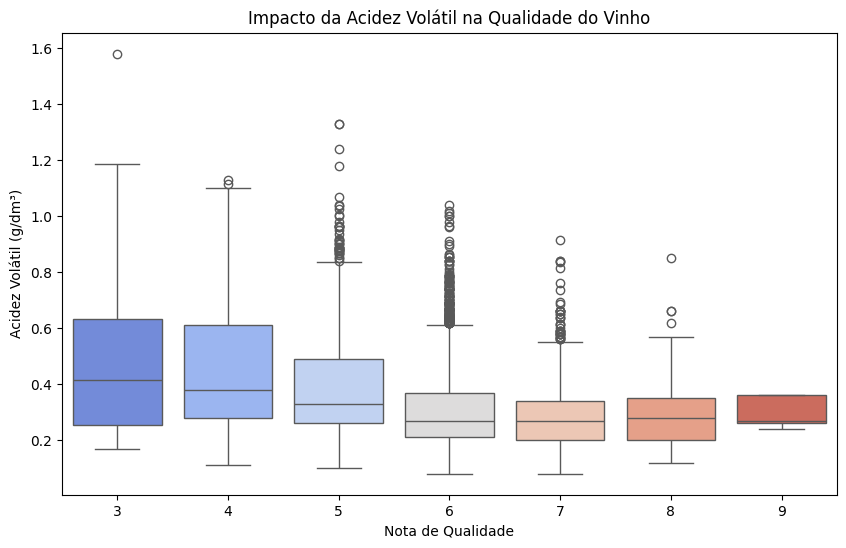

In [13]:
correlacao = df_wine['volatile acidity'].corr(df_wine['quality'])

# Gerar o gráfico (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(x='quality', y='volatile acidity', data=df_wine, palette='coolwarm')
plt.title('Impacto da Acidez Volátil na Qualidade do Vinho')
plt.xlabel('Nota de Qualidade')
plt.ylabel('Acidez Volátil (g/dm³)')
plt.show()

É possível observar uma correlação negativa entre a acidez volátil e a qualidade do vinho, já que os vinhos que receberam as maiores notas possuem medianas de acidez volátil significativamente menores do que os vinhos de notas baixas.

##Relação dos tipos de vinhos e os conservantes

/tmp/ipykernel_277/3813816223.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='type', y='total sulfur dioxide', data=df_wine, palette={'tinto': '#800020', 'branco': '#F5F5DC'})


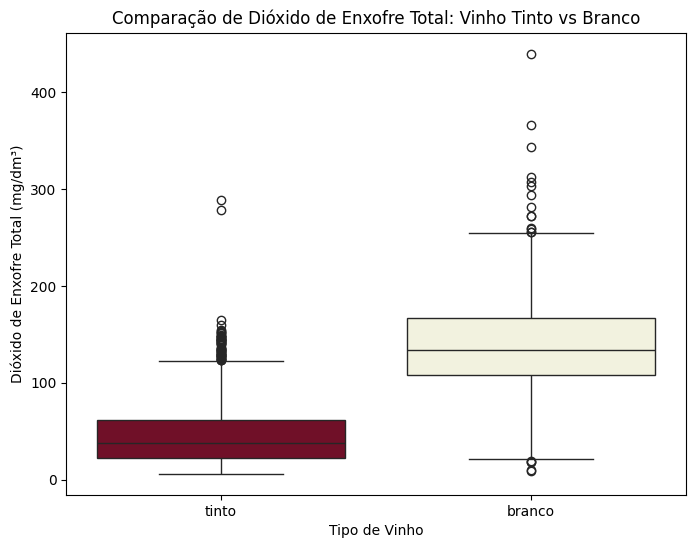

In [15]:
medias_conservantes = df_wine.groupby('type')['total sulfur dioxide'].mean()

plt.figure(figsize=(8, 6))
sns.boxplot(x='type', y='total sulfur dioxide', data=df_wine, palette={'tinto': '#800020', 'branco': '#F5F5DC'})
plt.title('Comparação de Dióxido de Enxofre Total: Vinho Tinto vs Branco')
plt.xlabel('Tipo de Vinho')
plt.ylabel('Dióxido de Enxofre Total (mg/dm³)')
plt.show()

A análise permite verificar que os vinhos brancos possuem maiores concentrações de dióxido de enxofre (conservantes) total em comparação aos vinhos tintos.

##Densidade X Álcool

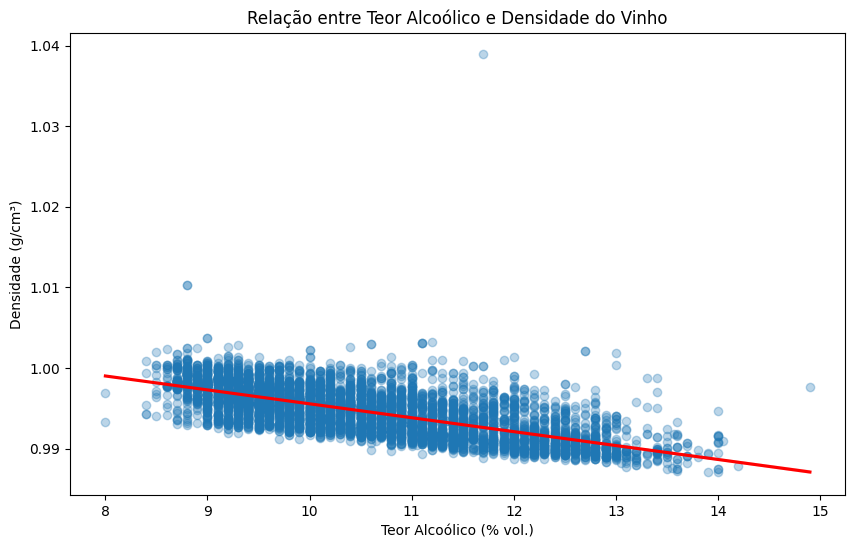

In [16]:
densidade_alcool = df_wine['density'].corr(df_wine['alcohol'])

plt.figure(figsize=(10, 6))
sns.regplot(x='alcohol', y='density', data=df_wine, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Relação entre Teor Alcoólico e Densidade do Vinho')
plt.xlabel('Teor Alcoólico (% vol.)')
plt.ylabel('Densidade (g/cm³)')
plt.show()

É possível verificar uma forte correlação negativa entre o teor alcólico e a densidade do vinho. O gráfico de disperção com a linha de regressão mostra uma clara tendência de queda, ou seja, quanto mais o álcool aumenta, menor é a densidade.